<a href="https://colab.research.google.com/github/Helothlad/Monte-Carlo-simulations/blob/main/Portfolio_VaR_CVaR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

In [5]:
#import data, return covariance matrix
def get_data(stocks, start, end):
  stockData = yf.download(stocks, start, end)
  stockData = stockData['Close']
  returns = stockData.pct_change()
  meanReturns = returns.mean()
  covMatrix = returns.cov()
  return meanReturns, covMatrix


In [6]:
stocks = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ', 'PG', 'XOM', 'CAT', 'NEE', 'RTX']
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=300)
meanReturns, covMatrix = get_data(stocks, startDate, endDate)
meanReturns
covMatrix


/tmp/ipython-input-45622363.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockData = yf.download(stocks, start, end)
[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,CAT,JNJ,JPM,MSFT,NEE,PG,RTX,XOM
Ticker,,,,,,,,,,
AAPL,0.000453,0.000289,0.000232,0.000029,0.000196,0.000167,0.000089,0.000068,0.000093,0.000138
AMZN,0.000289,0.000524,0.000237,-0.000042,0.000213,0.000209,0.000046,0.000004,0.000101,0.000105
CAT,0.000232,0.000237,0.000408,0.000008,0.000189,0.000152,0.000054,0.000015,0.000099,0.000115
JNJ,0.000029,-0.000042,0.000008,0.000150,0.000012,-0.000020,0.000067,0.000068,0.000023,0.000020
JPM,0.000196,0.000213,0.000189,0.000012,0.000270,0.000136,0.000046,0.000028,0.000105,0.000093
MSFT,0.000167,0.000209,0.000152,-0.000020,0.000136,0.000235,0.000034,-0.000004,0.000087,0.000058
NEE,0.000089,0.000046,0.000054,0.000067,0.000046,0.000034,0.000312,0.000075,0.000039,0.000067
PG,0.000068,0.000004,0.000015,0.000068,0.000028,-0.000004,0.000075,0.000144,0.000031,0.000039
RTX,0.000093,0.000101,0.000099,0.000023,0.000105,0.000087,0.000039,0.000031,0.000316,0.000075


In [7]:
weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)
weights

array([0.09384974, 0.17239696, 0.18808795, 0.08236638, 0.05175439,
       0.05057384, 0.13708034, 0.04301985, 0.15240639, 0.02846417])

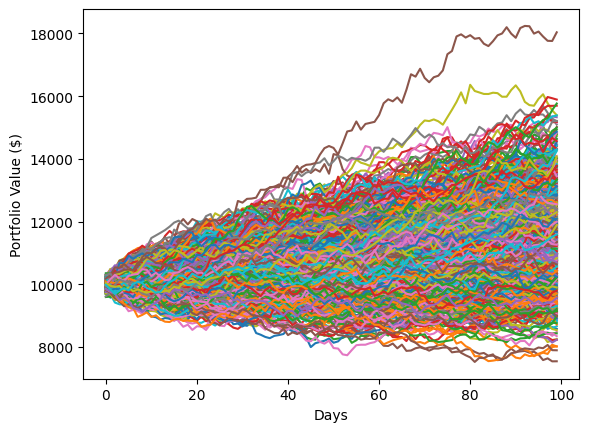

In [8]:
#Monte Carlo Method
#Number of simulations
mc_sims = 1000
T = 100 #Timeframe in days
meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)

initialPortfolio = 10000

for m in range(0, mc_sims):
  Z = np.random.normal(size=(T, len(weights)))
  L = np.linalg.cholesky(covMatrix)
  dailyReturns = meanM + np.inner(L, Z)
  portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T) + 1) * initialPortfolio

plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.show()

In [9]:
def mcVar(returns, alpha=5):
  # Input: pandas series of returns
  # Output: percentile on reuturn distribution to a given confidence level alpha

  if isinstance(returns, pd.Series):
    return np.percentile(returns, alpha)
  else:
    raise TypeError("Expected a pandas data series.")

In [10]:
def mcCVar(returns, alpha=5):
  # Input: pandas series of returns
  # Output: CVar or a expected shortfall to given confidence level alpha

  if isinstance(returns, pd.Series):
    belowVar = returns <= mcVar(returns, alpha=alpha)
    return returns[belowVar].mean()
  else:
    raise TypeError("Expected a pandas data series.")

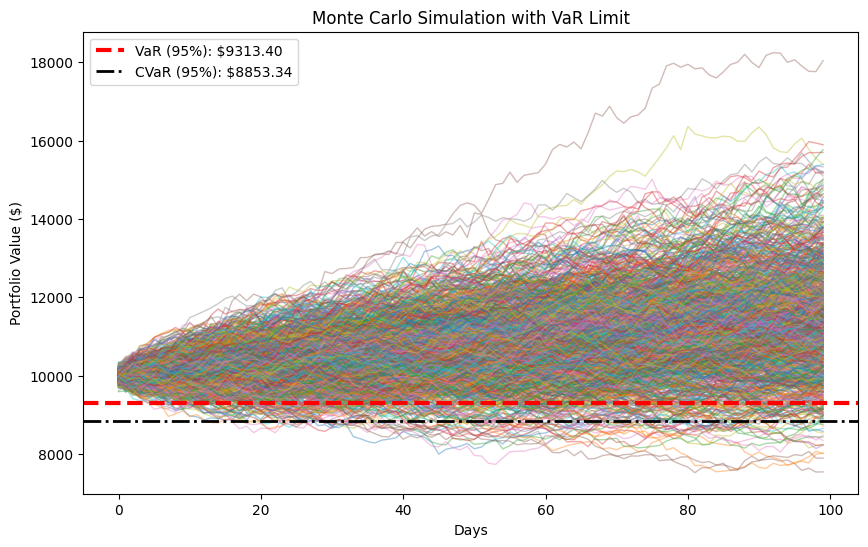

Initial Portfolio: $10000
Value at Risk (VaR) Amount: $686.60
Conditional VaR (CVaR) Amount: $1146.66


In [14]:
# ... (Your existing simulation loop code here) ...

# 1. Get the results of the LAST day (Day 100)
portResults = pd.Series(portfolio_sims[-1,:])

# 2. Calculate the Threshold (The dollar value where the 5% cut-off happens)
# Note: We use the raw value for plotting, not the difference from initial
var_value_threshold = mcVar(portResults, alpha=5)
cvar_value_threshold = mcCVar(portResults, alpha=5)

# 3. Plotting
plt.figure(figsize=(10,6))
plt.plot(portfolio_sims, linewidth=1, alpha=0.4) # alpha makes lines transparent so you can see the red line
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.title('Monte Carlo Simulation with VaR Limit')

# Add the VaR Line
plt.axhline(y=var_value_threshold, color='red', linestyle='--', linewidth=3, label=f'VaR (95%): ${var_value_threshold:.2f}')

# Optional: Add CVaR Line (usually lower than VaR)
plt.axhline(y=cvar_value_threshold, color='black', linestyle='-.', linewidth=2, label=f'CVaR (95%): ${cvar_value_threshold:.2f}')

plt.legend()
plt.show()

# Print the text results
print(f"Initial Portfolio: ${initialPortfolio}")
print(f"Value at Risk (VaR) Amount: ${initialPortfolio - var_value_threshold:.2f}")
print(f"Conditional VaR (CVaR) Amount: ${initialPortfolio - cvar_value_threshold:.2f}")